In [1]:
!pip install --upgrade scikit-learn scikit-learn==1.7.2 xgboost==3.1.3 lightgbm==4.6.0 catboost==1.2.8
!pip install -qq pytabkit
from pytabkit import RealMLP_TD_Classifier, TabM_D_Classifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 17.6 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.2.0
    Uninstalling xgboost-3.2.0:
      Successfully uninstalled xgboost-3.2.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: catboost
    Found existing installation: catboost 1.2.10
    Uninstalling catboost-1.2.10:
      Successfully uninstalled catboost-1.2.10
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 6.6 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder, label_binarize, OrdinalEncoder, QuantileTransformer, TargetEncoder, RobustScaler, FunctionTransformer, KBinsDiscretizer
from category_encoders import CatBoostEncoder, MEstimateEncoder

from sklearn.ensemble import RandomForestClassifier, VotingClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier, HistGradientBoostingRegressor, AdaBoostRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import RidgeClassifier, LogisticRegression, LinearRegression, BayesianRidge, Ridge, ElasticNet, Lasso, LogisticRegressionCV
from sklearn import set_config
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import optuna
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, root_mean_squared_error, mean_squared_error, precision_recall_curve, make_scorer, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, matthews_corrcoef, r2_score, balanced_accuracy_score, average_precision_score
from scipy.stats import norm, skew
from scipy.special import expit, logit 

from colorama import Fore, Style, init
from copy import deepcopy
from sklearn.base import BaseEstimator, TransformerMixin
from pprint import pprint
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, StratifiedKFold, KFold, RepeatedKFold, cross_val_score, StratifiedGroupKFold
from sklearn.isotonic import IsotonicRegression
from xgboost import DMatrix, XGBClassifier, XGBRegressor
import xgboost as xgb
from lightgbm import log_evaluation, early_stopping, LGBMClassifier, LGBMRegressor, Dataset
import lightgbm
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from tqdm.notebook import tqdm
from optuna.samplers import TPESampler, CmaEsSampler
from optuna.pruners import HyperbandPruner
from functools import partial
from IPython.display import display_html, clear_output
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
import gc
import re
from typing import Literal, NamedTuple
from itertools import combinations
from matplotlib.colors import LinearSegmentedColormap
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D
from sklearn.inspection import permutation_importance
from scipy.optimize import minimize

import keras
from keras.models import Sequential
from keras import layers
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

import math
import random
from copy import deepcopy
from typing import Any, Literal, NamedTuple, Optional
import torch

E0000 00:00:1778951902.036283      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778951902.118195      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778951902.783270      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778951902.783317      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778951902.783321      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778951902.783324      16 computation_placer.cc:177] computation placer already registered. Please check linka

# <p style="border-radius: 40px; color: white; font-weight: bold; font-size: 150%; text-align: center; background-color:#3cb371; padding: 5px 5px 5px 5px;">Configuration</p>

In [3]:
class Config:
    target = 'PitNextLap'
    train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/train.csv', index_col='id')
    test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/test.csv', index_col='id')
    submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv')
    orig = pd.read_csv('/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv')[train.columns]
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    state = 42
    n_splits = 5
    early_stop = 100
    metric = 'roc_auc'
    task_type = "binary"
    task_is_regression = task_type == 'regression'

    if task_is_regression:
        n_classes = 1
        folds = KFold(n_splits=n_splits, shuffle=True, random_state=state)
    else:
        if task_type == "binary":
            n_classes = 2
        else:
            n_classes = train[target].nunique()
        labels = train[target].unique()
        folds = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)  

# <p style="border-radius: 40px; color: white; font-weight: bold; font-size: 150%; text-align: center; background-color:#3cb371; padding: 5px 5px 5px 5px;">EDA</p>

In [4]:
class EDA(Config):
    
    def __init__(self):
        super().__init__()

        self.cat_features = self.train.drop(self.target, axis=1).select_dtypes(include=['object', 'bool']).columns.tolist()
        self.num_features = self.train.drop(self.target, axis=1).select_dtypes(exclude=['object', 'bool']).columns.tolist()
        self.data_info()
        self.heatmap()
        self.dist_plots()
        self.cat_feature_plots()
        if self.task_is_regression:
            self.target_plot()
        else:
            self.target_pie()
                
    def data_info(self):
        
        for data, label in zip([self.train, self.test], ['Train', 'Test']):
            table_style = [{'selector': 'th:not(.index_name)',
                            'props': [('background-color', '#3cb371'),
                                      ('color', '#FFFFFF'),
                                      ('font-weight', 'bold'),
                                      ('border', '1px solid #DCDCDC'),
                                      ('text-align', 'center')]
                            }, 
                            {'selector': 'tbody td',
                             'props': [('border', '1px solid #DCDCDC'),
                                       ('font-weight', 'normal')]
                            }]
            print(Style.BRIGHT+Fore.GREEN+f'\n{label} head\n')
            display(data.head().style.set_table_styles(table_style))
                           
            print(Style.BRIGHT+Fore.GREEN+f'\n{label} info\n'+Style.RESET_ALL)               
            display(data.info())
                           
            print(Style.BRIGHT+Fore.GREEN+f'\n{label} describe\n')
            display(data.describe().drop(index='count', columns=self.target, errors = 'ignore').T
                    .style.set_table_styles(table_style).format('{:.3f}'))
            
            print(Style.BRIGHT+Fore.GREEN+f'\n{label} missing values\n'+Style.RESET_ALL)               
            display(data.isna().sum())
        return self
    
    def heatmap(self):
        print(Style.BRIGHT+Fore.GREEN+f'\nCorrelation Heatmap\n')
        plt.figure(figsize=(10, 10))
        corr = self.train[self.num_features+[self.target]].corr(method='spearman')
        sns.heatmap(corr, fmt = '0.2f', cmap = 'Greens', square=True, annot=True, linewidths=1, cbar=False)
        plt.show()
        
    def dist_plots(self):
        print(Style.BRIGHT+Fore.GREEN+f"\nDistribution analysis\n")
        df = pd.concat([self.train[self.num_features].assign(Source = 'Train'), 
                        self.test[self.num_features].assign(Source = 'Test'),], 
                        axis=0, ignore_index = True)

        fig, axes = plt.subplots(len(self.num_features), 2 ,figsize = (18, len(self.num_features) * 6), 
                                 gridspec_kw = {'hspace': 0.3, 
                                                'wspace': 0.2, 
                                                'width_ratios': [0.70, 0.30]
                                               }
                                )
        for i,col in enumerate(self.num_features):
            ax = axes[i,0]
            sns.kdeplot(data = df[[col, 'Source']], x = col, hue = 'Source', 
                        palette = ['#3cb371', '#ef5350'], ax = ax, linewidth = 2
                       )
            ax.set(xlabel = '', ylabel = '')
            ax.set_title(f"\n{col}")
            ax.grid()

            ax = axes[i,1]
            sns.boxplot(data = df, y = col, x=df.Source, width = 0.5,
                        linewidth = 1, fliersize= 1,
                        ax = ax, palette=['#3cb371', '#ef5350']
                       )
            ax.set_title(f"\n{col}")
            ax.set(xlabel = '', ylabel = '')
            ax.tick_params(axis='both', which='major')
            ax.set_xticklabels(['Train', 'Test'])

        plt.tight_layout()
        plt.show()
               
    def cat_feature_plots(self):
        fig, axes = plt.subplots(max(len(self.cat_features), 1), 2 ,figsize = (18, len(self.cat_features) * 6), 
                                 gridspec_kw = {'hspace': 0.5, 
                                                'wspace': 0.2,
                                               }
                                )
        if len(self.cat_features) == 1:
            axes = np.array([axes])
            
        for i, col in enumerate(self.cat_features):
            ax = axes[i,0]
            sns.barplot(data=self.train[col].value_counts().nlargest(10).reset_index(), x=col, y='count', ax=ax, color='#3cb371')
            ax.set(xlabel = '', ylabel = '')
            ax.set_title(f"\n{col} Train")
            
            ax = axes[i,1]
            sns.barplot(data=self.test[col].value_counts().nlargest(10).reset_index(), x=col, y='count', ax=ax, color='#ef5350')
            ax.set(xlabel = '', ylabel = '')
            ax.set_title(f"\n{col} Test")

        plt.tight_layout()
        plt.show()

    def target_pie(self):
        print(Style.BRIGHT+Fore.GREEN+f"\nTarget feature distribution\n")
        plt.figure(figsize=(6, 6))
        counts = (self.train[self.target].value_counts(normalize=True).reindex(list(range(self.train[self.target].nunique(dropna=True))), fill_value=0))
        plt.pie(counts.values,
                labels=self.labels,
                autopct='%1.2f%%',
                colors=['#5c9ded', '#3cb371','#ef5350'])
        plt.show()

    def target_plot(self):
        print(Style.BRIGHT+Fore.GREEN+f"\nTarget feature distribution\n")
        
        fig, axes = plt.subplots(1, 2 ,figsize = (14, 6), 
                                 gridspec_kw = {'hspace': 0.3, 
                                                'wspace': 0.2, 
                                                'width_ratios': [0.70, 0.30]
                                               }
                                )
        ax = axes[0]
        sns.kdeplot(data = self.train[self.target], 
                    color = '#3cb371', ax = ax, linewidth = 2
                   )
        ax.set(xlabel = '', ylabel = '')
        ax.set_title(f"\n{self.target}")
        ax.grid()

        ax = axes[1]
        sns.boxplot(data = self.train, y = self.target, width = 0.5,
                    linewidth = 1, fliersize= 1,
                    ax = ax, color = '#3cb371'
                   )
        ax.set_title(f"\n{self.target}")
        ax.set(xlabel = '', ylabel = '')
        ax.tick_params(axis='both', which='major')

        plt.tight_layout()
        plt.show() 


Train head



,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
id,,,,,,,,,,,,,,,
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.000000,8,78.491000,-7.564000,21.019000,0.714286,5.000000,1.000000
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.000000,4,75.095000,-32.617000,-223.207000,0.346154,-3.000000,0.000000
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.000000,13,70.945000,-7.540000,-100.529000,0.819444,3.000000,1.000000
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.000000,7,94.361000,-7.324000,-7.324000,0.076923,0.000000,0.000000
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.000000,2,107.878000,8.965000,-14.139000,0.361111,3.000000,0.000000



Train info

<class 'pandas.core.frame.DataFrame'>
Index: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
 14  PitNextLap  

None


Train describe



...


Test describe



,mean,std,min,25%,50%,75%,max
Year,2023.528,1.025,2022.000,2023.000,2024.000,2024.000,2025.000
PitStop,0.136,0.343,0.000,0.000,0.000,0.000,1.000
LapNumber,23.050,17.002,1.000,9.000,19.000,36.000,77.000
Stint,1.784,0.949,1.000,1.000,2.000,2.000,8.000
TyreLife,14.161,9.853,1.000,6.000,12.000,20.000,77.000
Position,9.605,5.273,1.000,5.000,10.000,14.000,20.000
LapTime (s),90.987,20.855,67.017,82.634,90.485,98.485,2497.905
LapTime_Delta,-3.578,40.348,-2403.216,-8.874,-0.285,0.122,2433.472
Cumulative_Degradation,-25.849,54.920,-274.564,-46.814,-21.027,-6.188,2406.800
RaceProgress,0.337,0.253,0.013,0.128,0.269,0.513,1.000



Test missing values



Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
dtype: int64


Correlation Heatmap



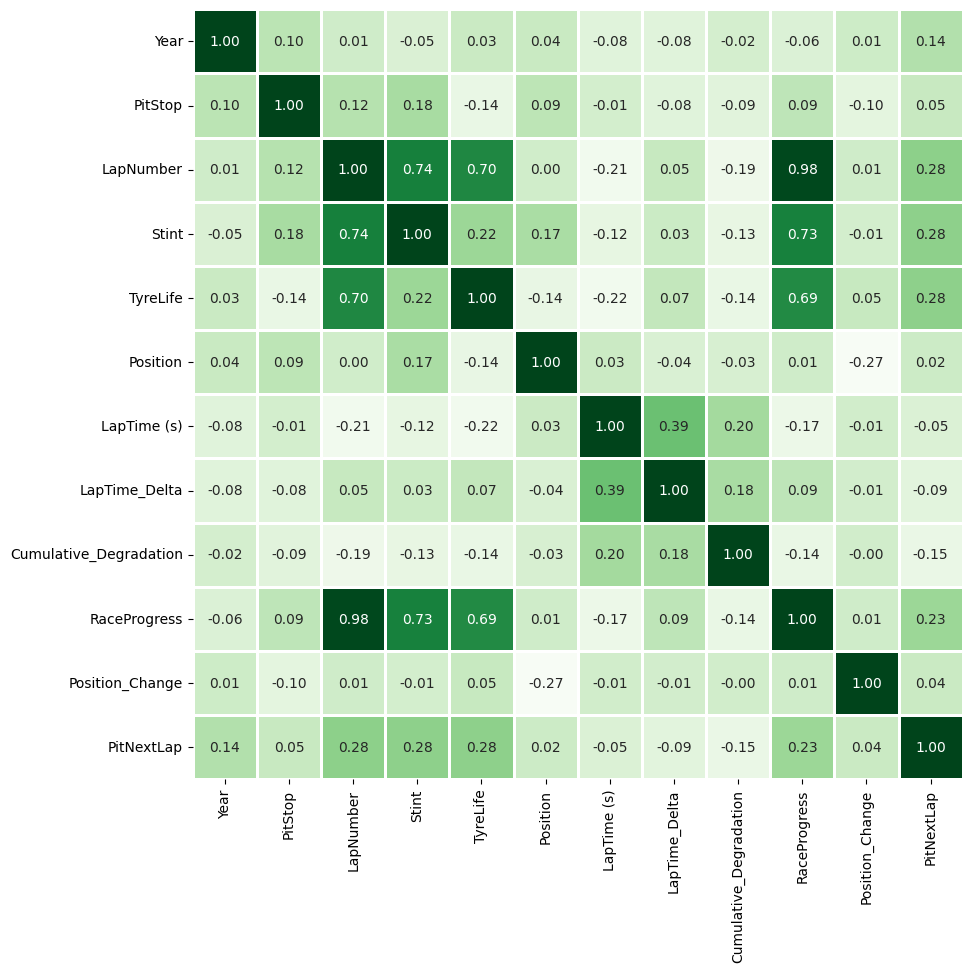


Distribution analysis



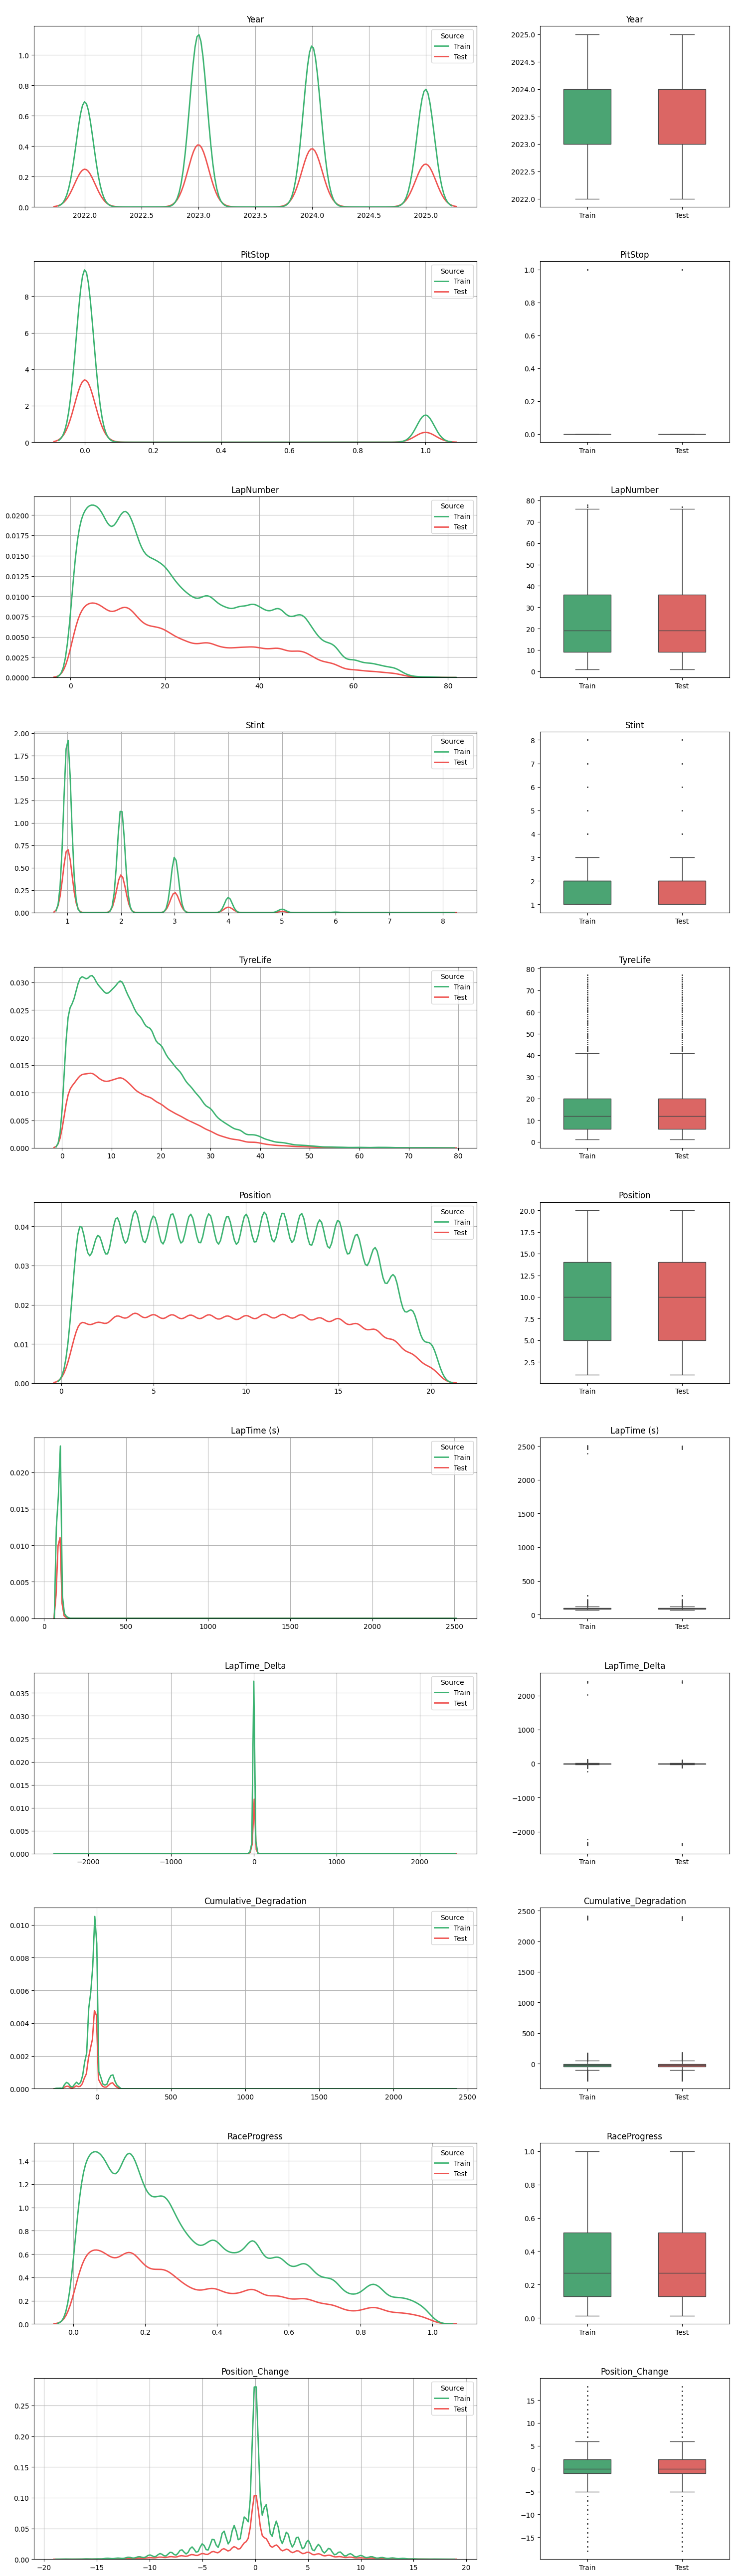

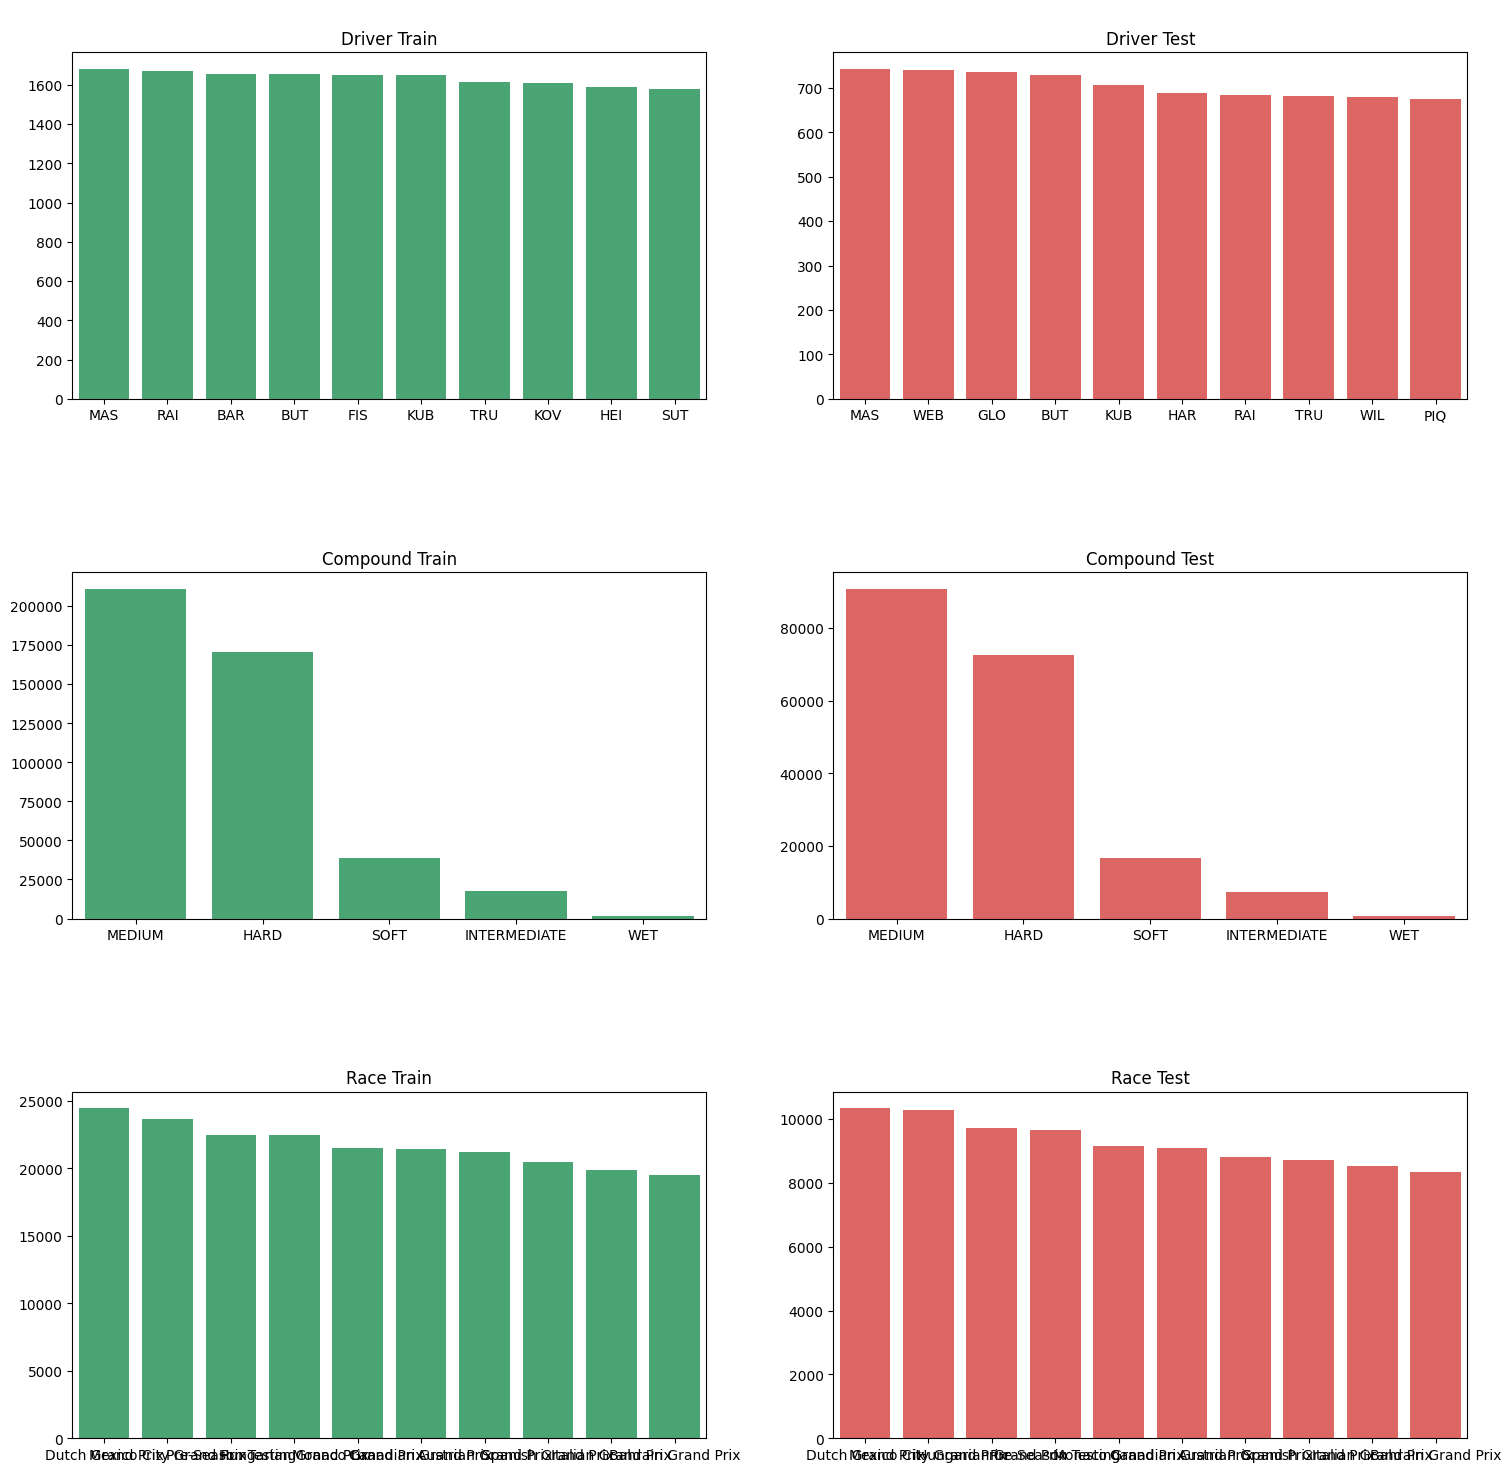


Target feature distribution



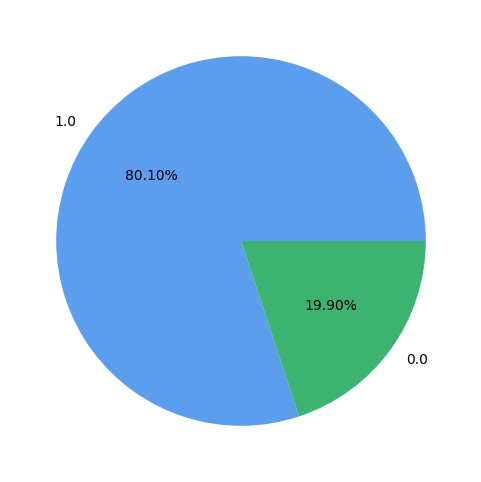

In [5]:
eda = EDA()

# <p style="border-radius: 40px; color: white; font-weight: bold; font-size: 150%; text-align: center; background-color:#3cb371; padding: 5px 5px 5px 5px;">Preprocessing</p>

In [6]:
class Preprocessing:
    def __init__(self, target):
        self.target = target
        self._fitted = False

    def fit_transform(self, X_train: pd.DataFrame, y_train: pd.Series, orig: pd.DataFrame = None):
        self.fit(X_train, y_train, orig=orig)
        return self.transform(X_train)

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series, orig: pd.DataFrame = None):
        self.X_train_ = X_train.copy()
        self.y_train_ = y_train.copy()

        self.num_features_ = self.X_train_.select_dtypes(exclude=['object', 'bool', 'category']).columns.tolist()
        self.cat_features_ = self.X_train_.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
        
        self._orig_stats = {}

        if orig is not None:
            self.orig_ = orig.copy()
            self._fit_orig_target_stats(self.cat_features_ + self.num_features_)

        self._fit_feature_engineering(self.X_train_)
        X_fe_train = self._apply_feature_engineering(self.X_train_)

        self._fit_frequency_encoding(X_fe_train)
        X_ready = self._apply_frequency_encoding(X_fe_train)
        
        X_ready = self._finalize_types(X_ready, fit=True)

        self._fitted = True
        return self

    def transform(self, X: pd.DataFrame):
        if not self._fitted:
            raise RuntimeError("Preprocessing is not fitted. Call fit() first.")

        X = X.copy()

        X = self._apply_orig_target_stats(X)

        X = self._apply_feature_engineering(X)

        X = self._apply_frequency_encoding(X)

        X = self._finalize_types(X, fit=False)

        for c in self.cat_features:
            X[c] = X[c].astype(object).fillna('NaN').astype('category')

        return X, self.cat_features, self.num_features

    def _fit_orig_target_stats(self, cols):
        self._orig_global_mean = float(self.orig_[self.target].mean())
        for c in cols:
            if c in self.orig_.columns:
                self._orig_stats[c] = self.orig_.groupby(c, observed=False)[self.target].mean()
            else:
                self._orig_stats[c] = pd.Series(dtype=float)

    def _apply_orig_target_stats(self, df):
        df = df.copy()
        for c, ser in self._orig_stats.items():
            col = f"{c}_org_mean"
            if c in df.columns and not ser.empty:
                df[col] = df[c].map(ser).astype(float).fillna(self._orig_global_mean)
            else:
                df[col] = self._orig_global_mean
        return df

    def _fit_feature_engineering(self, X_train):
        X_train = X_train.copy()

        self._highcard_num = [c for c in self.num_features_ if X_train[c].nunique(dropna=False) > 20]
        self.category_map = {}

        bin_config = {'RaceProgress': [200], 'LapTime (s)': [7]}
        for col, bins_list in bin_config.items():
            for n_bins in bins_list:
                for strategy in ['quantile']:
                    bin_name = f"{col}_{n_bins}_{strategy}_bin"
                    kb = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy=strategy, subsample=None)
                    kb.fit_transform(X_train[[col]]).ravel().astype('int32')
                    self.category_map[bin_name] = kb

        X_train['TyreLife_LapNumber_ratio'] = (X_train['TyreLife'] / X_train['LapNumber'].clip(lower=1)).astype('float32')  
        X_train['LapNumber_RaceProgress_ratio'] = (X_train['LapNumber'] / (X_train['RaceProgress'] + 1e-6)).astype('float32')
        
        self.num_to_cat = []
        for col in self.num_features_+['TyreLife_LapNumber_ratio', 'LapNumber_RaceProgress_ratio']:
            cat_name = f"{col}_cat"
            codes, uniques = np.floor(X_train[col]).factorize()
            self.category_map[col] = uniques
            X_train[cat_name] = codes.astype(str)
            self.num_to_cat.append(cat_name)
            
        for col in self.cat_features_+self.num_to_cat:
            count_name = f"{col}_count"
            count_map = X_train[col].value_counts()
            X_train[count_name] = X_train[col].map(count_map).fillna(0).astype('int32')
            self.category_map[count_name] = count_map

    def _apply_feature_engineering(self, df):
        df = df.copy()
            
        df['Race_Year_comb'] = df['Race'].astype(str) + '_' + df['Year'].astype(str)
        df['Race_Compound_comb'] = df['Race'].astype(str) + '_' + df['Compound'].astype(str)
        
        df['TyreLife_LapNumber_ratio'] = (df['TyreLife'] / df['LapNumber'].clip(lower=1)).astype('float32')
        df['LapNumber_RaceProgress_ratio'] = (df['LapNumber'] / (df['RaceProgress'] + 1e-6)).astype('float32')
        df['LapTime (s)_*_Cumulative_Degradation'] = (df['LapTime (s)'] * df['Cumulative_Degradation']).astype('float32')
        df['LapTime (s)_*_Cumulative_Degradation_abs'] = (df['LapTime (s)'] * df['Cumulative_Degradation'].abs()).astype('float32')
        df['LapTime (s)_Cumulative_Degradation_abs_ratio'] = (df['LapTime (s)'] / (df['Cumulative_Degradation'].abs() + 1e-6)).astype('float32')

        bin_config = {'RaceProgress': [200], 'LapTime (s)': [7]}
        for col, bins_list in bin_config.items():
            for n_bins in bins_list:
                for strategy in ['quantile']:
                    bin_name = f"{col}_{n_bins}_{strategy}_bin"
                    kb = self.category_map[bin_name]
                    binned = kb.transform(df[[col]]).ravel().astype('int32')
                    df[bin_name] = binned
                    df[bin_name] = df[bin_name].astype('category')
        
        for col in self.num_features_+['TyreLife_LapNumber_ratio', 'LapNumber_RaceProgress_ratio']:
            cat_name = f"{col}_cat"
            uniques = self.category_map.get(col, [])
            code_map = {cat: i for i, cat in enumerate(uniques)}
            mapped = np.floor(df[col]).map(code_map).fillna(-1).astype('int32')
            df[cat_name] = mapped.astype(str)

        for col in self.cat_features_+self.num_to_cat:
            count_name = f"{col}_count"
            count_map = self.category_map[count_name]
            df[count_name] = df[col].map(count_map).fillna(0).astype('int32')
                
        drop = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
        if drop:
            df.drop(drop, axis=1, inplace=True)

        return df

    def _fit_frequency_encoding(self, X):
        all_cats = list(dict.fromkeys(self.cat_features_+self.num_to_cat))
        self._fe_cols = [c for c in all_cats if c in X.columns]

        self._freq_encodings = {}
        for c in self._fe_cols:
            self._freq_encodings[c] = X[c].value_counts(normalize=True).to_dict()

    def _apply_frequency_encoding(self, X):
        X = X.copy()
        for c in getattr(self, "_fe_cols", []):
            mapping = self._freq_encodings.get(c, {})
            if c in X.columns:
                X[f"{c}_fe"] = X[c].map(mapping).astype(float).fillna(0.0)
            else:
                X[f"{c}_fe"] = 0.0
        return X
        
    def _finalize_types(self, X, fit=False):
        self.num_features = X.select_dtypes(exclude=['object', 'bool', 'category']).columns.tolist()
        self.cat_features = X.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
        return X

In [7]:
y = Config.train[Config.target]
X = Config.train.drop(Config.target, axis=1)
orig_y = Config.orig[Config.target]
orig_X = Config.orig.drop(Config.target, axis=1)

p = Preprocessing(Config.target)
X, cat_features, num_features = p.fit_transform(X, y, Config.orig)
test, _, _ = p.transform(Config.test)
orig_X, _, _ = p.transform(orig_X)

# <p style="border-radius: 40px; color: white; font-weight: bold; font-size: 150%; text-align: center; background-color:#3cb371; padding: 5px 5px 5px 5px;">Models</p>

**YDF model**

In [8]:
import contextlib
import io
from typing import Optional, Dict
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator
import ydf


class YDFModel(BaseEstimator, Config):
    def __init__(self,
                 learner_type: str = "RF",
                 params: Optional[Dict] = None):
        self.params = {} if params is None else params.copy()

        if learner_type == "RF":
            self.learner_class = ydf.RandomForestLearner
        elif learner_type == "GBT":
            self.learner_class = ydf.GradientBoostedTreesLearner
        else:
            raise ValueError(f"Unknown learner_type: {learner_type}")

        self.model = None

    def fit(self,
            X: pd.DataFrame,
            y: pd.Series,
            X_val: Optional[pd.DataFrame] = None,
            y_val: Optional[pd.Series] = None,
            sample_weight: Optional[np.ndarray] = None):
        assert isinstance(X, pd.DataFrame)
        assert isinstance(y, pd.Series)

        if not self.task_is_regression:
            y = y.astype(int)
            y_val = y_val.astype(int)

        if self.task_is_regression:
            self.n_classes = 1
        else:
            unique = np.unique(y)
            if len(unique) == 2:
                self.n_classes = 2
            else:
                self.n_classes = len(unique)

        target = y.name
        params = self.params.copy()
        params["label"] = target
        params["task"] = (ydf.Task.REGRESSION if self.task_is_regression
                          else ydf.Task.CLASSIFICATION)

        train_df = X.copy()
        train_df[target] = y.values

        valid_df = None
        if X_val is not None and y_val is not None:
            valid_df = X_val.copy()
            valid_df[target] = y_val.values

        supports_valid = self.learner_class is ydf.GradientBoostedTreesLearner

        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            learner = self.learner_class(**params)
            if supports_valid and valid_df is not None:
                try:
                    self.model = learner.train(train_df, valid=valid_df, sample_weights=sample_weight)
                except TypeError:
                    self.model = learner.train(train_df, valid=valid_df)
            else:
                try:
                    self.model = learner.train(train_df, sample_weights=sample_weight)
                except TypeError:
                    self.model = learner.train(train_df)

        return self

    def _ensure_proba_shape(self, raw_pred: np.ndarray) -> np.ndarray:
        proba = np.asarray(raw_pred)
    
        if not self.task_is_regression and self.n_classes == 2:
            if proba.ndim == 1:
                proba = np.vstack([1 - proba, proba]).T
            elif proba.ndim == 2 and proba.shape[1] == 1:
                proba = np.hstack([1 - proba, proba])
            return proba
    
        if proba.ndim == 1:
            proba = proba.reshape(-1, 1)
            return proba
    
        if proba.ndim == 2:
            return proba
    
        return proba

    def predict(self, X: pd.DataFrame):
        assert isinstance(X, pd.DataFrame)
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            raw = self.model.predict(X)

        if self.task_is_regression:
            return np.asarray(raw)

        proba = self._ensure_proba_shape(raw)
        return proba

    def predict_proba(self, X: pd.DataFrame):
        if self.task_is_regression:
            raise AttributeError("predict_proba is not available for regression task")
        return self.predict(X)

**Keras NN model**

In [9]:
import tensorflow as tf
from tensorflow.keras.layers import Lambda, Input, Embedding, Flatten, Dense, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, AdamW
from sklearn.base import BaseEstimator
       
class KerasTabularModel(BaseEstimator, Config):
    def __init__(self, embedding_dim_func=None,
                 hidden_units=[256,128,64],
                 dropout=0.3,
                 learning_rate=1e-3,
                 epochs=20,
                 batch_size=64,
                 early_stopping_patience=3,
                 reduce_lr_patience=1,
                cat_features=[],
                num_features=[]):

        self.embedding_dim_func = embedding_dim_func or (lambda c: int(np.ceil(np.sqrt(c))))
        self.hidden_units = hidden_units
        self.dropout = dropout
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.cat_features = cat_features
        self.num_features = num_features
        self.early_stopping_patience = early_stopping_patience
        self.reduce_lr_patience = reduce_lr_patience
        
    def _build_model(self):   
        # 1) Inputs
        cat_input = Input(shape=(len(self.cat_features),), name="cat_input")
        num_input = Input(shape=(len(self.num_features),), name="num_input")
    
        # 2) Category embeddings
        embs = []
        for j, card in enumerate(self.cat_cardinalities):
            emb_dim = int(np.ceil(np.sqrt(card)))
            emb_layer = layers.Embedding(input_dim=card,
                                         output_dim=emb_dim,
                                         name=f"emb_cat_{j}")
            xj = emb_layer(cat_input[:,j])
            embs.append(layers.Flatten()(xj))    
    
        # 3) Concatenate all tokens
        x = layers.Concatenate(axis=-1, name="all_tokens")(embs + [num_input])
    
        # 4) Fully connected
        for idx, units in enumerate(self.hidden_units):
            x = layers.Dense(units,
                             activation='relu',
                             kernel_regularizer=tf.keras.regularizers.l2(1e-5),
                             name=f"dense_{idx}")(x)
            x = layers.Dropout(self.dropout, name=f"dropout_dense_{idx}")(x)
            x = layers.BatchNormalization(name=f"bn_{idx}")(x)
                
        # 5) Output
        if self.task_type == 'regression':
            output = layers.Dense(1, activation='linear', name='output')(x)
            loss, metrics = 'mse', ['mse']
        elif self.task_type == 'binary':
            output = layers.Dense(1, activation='sigmoid', name='output')(x)
            loss, metrics = 'binary_crossentropy', ['accuracy']
        else:
            output = layers.Dense(self.n_classes,
                                  activation='softmax',
                                  name='output')(x)
            loss, metrics = 'sparse_categorical_crossentropy', ['accuracy']
    
        # 6) Assembly and compilation
        self.model = Model(inputs=[cat_input, num_input], outputs=output)
        self.model.compile(optimizer=AdamW(learning_rate=self.learning_rate, weight_decay=1e-5),
                           loss=loss,
                           metrics=metrics
                          )

    def _process_X(self, X: pd.DataFrame, training=False):
        
        X_cat = X[self.cat_features]
        X_num = X[self.num_features] if self.num_features else np.zeros((len(X), 0))
        if training:
            self._cont_feature_preprocessor = QuantileTransformer(
                n_quantiles=max(min(len(X) // 30, 1000), 10),
                output_distribution='normal',
                subsample=10**9,
            )
            X_num = self._cont_feature_preprocessor.fit_transform(X_num)
            self._cat_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
            X_cat = self._cat_encoder.fit_transform(X_cat)
        else:
            X_num = self._cont_feature_preprocessor.transform(X_num)
            X_cat = self._cat_encoder.transform(X_cat)
        return [X_cat, X_num]

    def fit(self, X: pd.DataFrame, y: pd.Series, eval_set=None, verbose=1):
        self.cat_cardinalities = [X[col].nunique() for col in self.cat_features]
        X_proc = self._process_X(X, training=True)
        self._build_model()
        val_data = None
        if eval_set is not None:
            X_val, y_val = eval_set[0]
            X_val_proc = self._process_X(X_val)
            val_data = (X_val_proc, y_val)
        return self.model.fit(X_proc, y,
                              epochs=self.epochs,
                              batch_size=self.batch_size,
                              validation_data=val_data,
                              verbose=verbose,
                              callbacks=[keras.callbacks.ReduceLROnPlateau(patience=self.reduce_lr_patience),
                                         keras.callbacks.EarlyStopping(patience=self.early_stopping_patience,
                                         restore_best_weights=True)
                                        ])

    def predict(self, X: pd.DataFrame):
        X_proc = self._process_X(X)
        preds = self.model.predict(X_proc)
        if self.task_type == 'regression':
            return preds.squeeze()
        elif self.task_type == 'binary':
            return (preds.squeeze() > 0.5).astype(int)
        else:  # multiclass
            return preds.argmax(axis=1)

    def predict_proba(self, X: pd.DataFrame):
        if self.task_type == 'regression':
            raise AttributeError("predict_proba is not available for regression task")
        X_proc = self._process_X(X)
        preds = self.model.predict(X_proc)
        if self.task_type == 'binary':
            preds = preds.squeeze()
            return np.vstack([1-preds, preds]).T
        else:
            return preds

In [10]:
models = {
    'XGB_16': XGBClassifier(**{'n_estimators': 50000,
                               'learning_rate': 0.01,
                               'max_depth': 6,
                               'random_state': Config.state,
                               'objective': 'binary:logistic',
                               'eval_metric': 'auc',
                               'enable_categorical': True,
                               'device': 'cuda',
                               'max_bin': 5000,
                               }),
    'XGB2_21': XGBClassifier(**{'n_estimators': 50000,
                                'learning_rate': 0.01,
                                'random_state': Config.state,
                                'objective': 'binary:logistic',
                                'eval_metric': 'auc',
                                'enable_categorical': True,
                                'device': 'cuda',
                                'max_bin': 5000,
                                'lambda': 8.162374349037115,
                                'alpha': 8.354463958574286, 
                                'colsample_bytree': 0.1450999139156032,
                                'subsample': 0.8570122278990485,
                                'max_depth': 10,
                                'min_child_weight': 2
                               }),
    'XGB3_2': XGBClassifier(**{'n_estimators': 50000,
                               'learning_rate': 0.01,
                               'random_state': Config.state,
                               'objective': 'binary:logistic',
                               'eval_metric': 'auc',
                               'enable_categorical': True,
                               'device': 'cuda',
                               'max_bin': 5000,
                               'lambda': 7.336548282259911,
                               'alpha': 4.717742768334144, 
                               'colsample_bytree': 0.2467816540614318, 
                               'subsample': 0.8468669571395848, 
                               'max_depth': 11, 
                               'min_child_weight': 6
                              }),
    'XGB4': XGBClassifier(**{'n_estimators': 50000,
                             'learning_rate': 0.01,
                             'random_state': Config.state,
                             'objective': 'binary:logistic',
                             'eval_metric': 'auc',
                             'enable_categorical': True,
                             'device': 'cuda',
                             'max_bin': 5000,
                             'lambda': 0.25356710846329644,
                             'alpha': 3.9431008774671916,
                             'colsample_bytree': 0.17774825158281427, 
                             'subsample': 0.6948146928263638, 
                             'max_depth': 14,
                             'min_child_weight': 9
                            }),
    'Realmlp_2': RealMLP_TD_Classifier(**{'val_metric_name': '1-balanced_accuracy',
                                          'device': 'cuda',
                                          'random_state': 42,
                                          'verbosity': 2,
                                          'n_epochs': 100,
                                          'batch_size': 256, 
                                          'n_ens': 8, 
                                          'use_early_stopping': True,
                                          'early_stopping_additive_patience': 10,
                                          'early_stopping_multiplicative_patience': 1,
                                          'act': "mish",
                                          'embedding_size': 8,
                                          'first_layer_lr_factor': 0.5962121993798933,
                                          'hidden_sizes': "rectangular",
                                          'hidden_width': 384,
                                          'lr': 0.04, 
                                          'ls_eps': 0.011498317194338772,
                                          'ls_eps_sched': "coslog4",
                                          'max_one_hot_cat_size': 18,
                                          'n_hidden_layers': 4, 
                                          'p_drop': 0.07301419697186451,
                                          'p_drop_sched': "flat_cos",
                                          'plr_hidden_1': 16, 
                                          'plr_hidden_2': 8,
                                          'plr_lr_factor': 0.1151437622270563,
                                          'plr_sigma': 2.3316811282666916,
                                          'scale_lr_factor': 2.244801835541429,
                                          'sq_mom': 1.0 - 0.011834054955582318,
                                          'wd': 0.02369230879235962,
                                         }),
    'Realmlp2_3': RealMLP_TD_Classifier(**{'random_state': 42,
                                           'verbosity': 2,
                                           'val_metric_name': '1-balanced_accuracy',
                                           'n_ens': 8,
                                           'n_epochs': 3,
                                           'batch_size': 256,
                                           'use_early_stopping': True,
                                           'early_stopping_additive_patience': 10,
                                           'early_stopping_multiplicative_patience': 1,
                                           'lr': 0.075,
                                           'wd': 0.0236,
                                           'sq_mom': 0.988,
                                           'lr_sched': 'flat_anneal',
                                           'first_layer_lr_factor': 0.25, 
                                           'add_front_scale': False,
                                           'bias_init_mode': 'neg-uniform-dynamic-2',
                                           'embedding_size': 6,
                                           'max_one_hot_cat_size': 18,
                                           'act': 'silu',
                                           'p_drop': 0.05,
                                           'p_drop_sched': 'expm4t',
                                           'plr_hidden_1': 16,
                                           'plr_hidden_2': 8,
                                           'plr_act_name': 'gelu',
                                           'plr_lr_factor': 0.1151,
                                           'plr_sigma': 2.33,
                                           'ls_eps': 0.01,
                                           'ls_eps_sched': 'sqrt_cos'
                                           }),
    'Realmlp3_8': RealMLP_TD_Classifier(**{'random_state': 42,
                                           'verbosity': 2,
                                           'val_metric_name': '1-auc_ovr',        
                                           'n_ens': 8,
                                           'n_epochs': 4,
                                           'batch_size': 256,
                                           'use_early_stopping': False,
                                           'early_stopping_additive_patience': 10,
                                           'early_stopping_multiplicative_patience': 1,        
                                           'lr': 0.07,
                                           'wd': 0.018,
                                           'sq_mom': 0.98,
                                           'lr_sched': 'cos_anneal',
                                           'first_layer_lr_factor': 0.25,        
                                           'embedding_size': 6,
                                           'max_one_hot_cat_size': 18,
                                           'hidden_sizes': [512, 256, 128],
                                           'act': 'silu',
                                           'p_drop': 0.05,
                                           'p_drop_sched': 'expm4t',        
                                           'plr_hidden_1': 16,
                                           'plr_hidden_2': 8,
                                           'plr_act_name': 'gelu',
                                           'plr_lr_factor': 0.1151,
                                           'plr_sigma': 2.33,        
                                           'ls_eps': 0.01,
                                           'ls_eps_sched': 'sqrt_cos',        
                                           'add_front_scale': False,
                                           'bias_init_mode': 'neg-uniform-dynamic-2',
                                           'tfms': ['one_hot', 'median_center', 'robust_scale',
                                                    'smooth_clip', 'embedding', 'l2_normalize'],
                                           }),
    'Realmlp4_7': RealMLP_TD_Classifier(**{'random_state': 42,
                                           'verbosity': 2,
                                           'val_metric_name': '1-auc_ovr',            
                                           'n_ens': 24,
                                           'n_epochs': 6,
                                           'batch_size': 256,
                                           'use_early_stopping': False,
                                           'early_stopping_additive_patience': 10,
                                           'early_stopping_multiplicative_patience': 1,            
                                           'lr': 0.01,
                                           'wd': 0.016,
                                           'sq_mom': 0.99,
                                           'lr_sched': 'lin_cos_log_15',
                                           'first_layer_lr_factor': 0.25,            
                                           'embedding_size': 6,
                                           'max_one_hot_cat_size': 18,
                                           'hidden_sizes': [512, 256, 128],
                                           'act': 'silu',
                                           'p_drop': 0.05,
                                           'p_drop_sched': 'expm4t',            
                                           'plr_hidden_1': 16,
                                           'plr_hidden_2': 8,
                                           'plr_act_name': 'gelu',
                                           'plr_lr_factor': 0.1151,
                                           'plr_sigma': 2.33,            
                                           'ls_eps': 0.01,
                                           'ls_eps_sched': 'sqrt_cos',            
                                           'add_front_scale': False,
                                           'bias_init_mode': 'neg-uniform-dynamic-2',
                                           'tfms': ['one_hot', 'median_center', 'robust_scale', 'smooth_clip', 'embedding', 'l2_normalize'],
                                           }),
    'LGBM_3': LGBMClassifier(**{'random_state': Config.state,
                                'early_stopping_round': Config.early_stop,
                                'verbose': -1,
                                'n_estimators': 20000,
                                'metric': 'auc',
                                'objective': 'binary',
                                'learning_rate': 0.01,
                                'max_depth': 6,
                                'max_bin': 5000,
                               }),
    'LGBM2_12': LGBMClassifier(**{'random_state': Config.state,
                                  'early_stopping_round': Config.early_stop,
                                  'verbose': -1,
                                  'n_estimators': 20000,
                                  'metric': 'auc',
                                  'objective': 'binary',
                                  'learning_rate': 0.01,
                                  'max_bin': 5000,
                                  'max_depth': 11, 
                                  'min_child_samples': 94, 
                                  'subsample': 0.6522179123688497,
                                  'colsample_bytree': 0.32842983929259567,
                                  'num_leaves': 140, 
                                  'reg_alpha': 1.0377177748954165,
                                  'reg_lambda': 0.1613822177468191
                                  }),
    'LGBM3_2': LGBMClassifier(**{'random_state': Config.state,
                                 'early_stopping_round': Config.early_stop,
                                 'verbose': -1,
                                 'n_estimators': 20000,
                                 'metric': 'auc',
                                 'objective': 'binary',
                                 'learning_rate': 0.01,
                                 'max_bin': 5000,
                                 "feature_pre_filter": False,
                                 'max_depth': 12,
                                 'min_child_samples': 33, 
                                 'subsample': 0.26685144787781945, 
                                 'colsample_bytree': 0.23457900771427878, 
                                 'num_leaves': 381,
                                 'reg_alpha': 5.499071258569893,
                                 'reg_lambda': 0.02547086863080793
                                }),
    'LGBM4': LGBMClassifier(**{'random_state': Config.state,
                               'early_stopping_round': Config.early_stop,
                               'verbose': -1,
                               'n_estimators': 20000,
                               'metric': 'auc',
                               'objective': 'binary',
                               'learning_rate': 0.01,
                               'max_bin': 5000,
                               'max_depth': 14, 
                               'min_child_samples': 136, 
                               'subsample': 0.49213571528068917,
                               'colsample_bytree': 0.2003244975377485, 
                               'num_leaves': 431,
                               'reg_alpha': 0.10964422705802229, 
                               'reg_lambda': 6.321652986460238
                              }),
    'LR_6': LogisticRegression(penalty="l2", 
                               solver="lbfgs", 
                               C = 1.0, 
                               random_state = Config.state, 
                               max_iter = 1000,
                               class_weight='balanced',
                               n_jobs=-1
                               ),
    'CAT_2': CatBoostClassifier(**{'verbose': 0,
                                   'loss_function':'Logloss',
                                   'random_state': Config.state,
                                   'early_stopping_rounds': Config.early_stop,
                                   'eval_metric': "AUC",
                                   'n_estimators' : 20000,
                                   'learning_rate': 0.01,
                                   "task_type": "GPU",
                                   'depth': 8,
                                  }),
    'CAT2_11': CatBoostClassifier(**{'verbose': 0,
                                     'loss_function':'Logloss',
                                     'random_state': Config.state,
                                     'early_stopping_rounds': Config.early_stop,
                                     'eval_metric': "AUC",
                                     'n_estimators' : 20000,
                                     'learning_rate': 0.05,
                                     "task_type": "GPU",
                                     'depth': 10,
                                     'min_data_in_leaf': 54, 
                                     'l2_leaf_reg': 8.04214109088981,
                                     'bagging_temperature': 0.12529500670009353,
                                     'random_strength': 8.965600403402266
                                    }),
    'CAT4_2': CatBoostClassifier(**{'verbose': 0,
                                    'loss_function':'Logloss',
                                    'random_state': Config.state,
                                    'early_stopping_rounds': Config.early_stop,
                                    'eval_metric': "AUC",
                                    'n_estimators' : 20000,
                                    'learning_rate': 0.01,
                                    "task_type": "GPU",
                                    'depth': 9, 
                                    'min_data_in_leaf': 26,
                                    'l2_leaf_reg': 6.457023621519966, 
                                    'bagging_temperature': 0.5995185332846042,
                                    'random_strength': 0.27483928483377495
                                   }),
    'NN_3': KerasTabularModel(hidden_units=[256,128], 
                              dropout=0.1,
                              epochs=30,
                              learning_rate=1e-3,
                              batch_size=1000
                             ),
    'HGB_3': HistGradientBoostingClassifier(**{'max_iter': 20000,
                                             'random_state': Config.state,
                                             'early_stopping': True,
                                             'categorical_features': "from_dtype",
                                             'learning_rate': 0.01,
                                             'loss': 'log_loss',
                                             'scoring': 'roc_auc',
                                             'tol': 1e-7,
                                             'l2_regularization': 9.206887135749392,
                                             'max_depth': 10,
                                             'max_leaf_nodes': 190,
                                             'min_samples_leaf': 65
                                             }),
    'YDF_GBT_3': YDFModel(learner_type="GBT", params={'num_trees': 600,
                                                      'random_seed': Config.state,
                                                      'growing_strategy': 'BEST_FIRST_GLOBAL',
                                                      'shrinkage': 0.1,
                                                      "early_stopping_num_trees_look_ahead": 50,
                                                      'categorical_algorithm': 'CART',
                                                      'max_depth': 3, 
                                                      'min_examples': 10,
                                                     }),
    'TabMD_4': TabM_D_Classifier(**{'batch_size': 'auto',
                                    'patience': 16,
                                    'allow_amp': True,
                                    'arch_type': 'tabm-mini',
                                    'tabm_k': 8,
                                    'gradient_clipping_norm': 1.0, 
                                    'share_training_batches': False,
                                    'lr': 1e-3,
                                    'weight_decay': 1e-3,
                                    'n_blocks': 3,
                                    'd_block': 512, 
                                    'dropout': 0.0, 
                                    'num_emb_type': 'pwl',
                                    'd_embedding': 32,
                                    'num_emb_n_bins': 119,
                                   }),
}

# <p style="border-radius: 40px; color: white; font-weight: bold; font-size: 150%; text-align: center; background-color:#3cb371; padding: 5px 5px 5px 5px;">Training</p>

In [11]:
class FeatureEncoder:
    def __init__(self, num_features, cat_features):
        self.num_features = num_features
        self.cat_features = cat_features
        self.ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        self.scaler = StandardScaler()
        self.ohe_cols = None

    def fit(self, X):
        self.ohe.fit(X[self.cat_features])
        self.ohe_cols = self.ohe.get_feature_names_out(self.cat_features)
        self.scaler.fit(X[self.num_features])
        
    def transform_fold(self, X_train, X_val, X_test):
        def transform(X):
            X[self.num_features] = self.scaler.transform(X[self.num_features])

            X_ohe = self.ohe.transform(X[self.cat_features])
            X_ohe_df = pd.DataFrame(X_ohe, columns=self.ohe_cols, index=X.index)   
            X = pd.concat([X.drop(columns=self.cat_features).reset_index(drop=True),
                                        X_ohe_df.reset_index(drop=True)], axis=1)
            return X
        return transform(X_train), transform(X_val), transform(X_test)

In [12]:
class Trainer(Config):
    
    def __init__(self, X, y, test, models, num_features, cat_features, training=True):
        self.X = X
        self.test = test
        self.y = y
        self.models = models
        self.training = training
        self.scores = pd.DataFrame(columns=['Score'], dtype=float)
        self.OOF_preds = pd.DataFrame(dtype=float)
        self.TEST_preds = pd.DataFrame(dtype=float)
        self.num_features = num_features
        self.cat_features = cat_features

    def ScoreMetric(self, y_true, y_pred):
        if self.task_type == "multiclass":
          y_label = np.argmax(y_pred, axis=1)
        elif self.task_type == "binary":
          y_label = (y_pred >= 0.5).astype(int)
        else:
          y_label = y_pred
            
        if self.metric == "roc_auc":
          return roc_auc_score(y_true, y_pred, multi_class="ovr") if self.task_type == "multiclass" else roc_auc_score(y_true, y_pred)
        if self.metric == "accuracy":
          return accuracy_score(y_true, y_label)
        if self.metric == "balanced_accuracy":
          return balanced_accuracy_score(y_true, y_label)
        if self.metric == "f1":
          return f1_score(y_true, y_label, average="weighted" if self.n_classes and self.n_classes > 2 else "binary")
        if self.metric == "precision":
          return precision_score(y_true, y_label, average="weighted" if self.n_classes and self.n_classes > 2 else "binary", zero_division=0)
        if self.metric == "recall":
          return recall_score(y_true, y_label, average="weighted" if self.n_classes and self.n_classes > 2 else "binary", zero_division=0)
        if self.metric == "mae":
          return mean_absolute_error(y_true, y_label)
        if self.metric == "r2":
          return r2_score(y_true, y_label)
        if self.metric == "rmse":
          return mean_squared_error(y_true, y_label, squared=False)
        if self.metric == "mse":
          return mean_squared_error(y_true, y_label, squared=True)

    def train(self, model, X, y, test, model_name):
        if self.task_type == "multiclass":
            oof_pred = np.zeros((X.shape[0], self.n_classes), dtype=float)
            test_pred = np.zeros((test.shape[0], self.n_classes), dtype=float)
        else:
            oof_pred = np.zeros(X.shape[0], dtype=float)
            test_pred = np.zeros(test.shape[0], dtype=float)
        
        print('='*20)
        print(model_name)
        params=model.get_params()
        
        for n_fold, (train_id, valid_id) in enumerate(self.folds.split(X, y)):
            X_train = X.iloc[train_id].copy()
            y_train = y.iloc[train_id]
            X_val = X.iloc[valid_id].copy()
            y_val = y.iloc[valid_id]
            X_test = test.copy()

            if model_name != 'Ensemble':
                X_train = pd.concat([X_train, orig_X], axis=0).reset_index(drop=True)
                y_train = pd.concat([y_train, orig_y], axis=0).reset_index(drop=True)
                X_train[self.cat_features] = X_train[self.cat_features].astype('category')
            
                te = TargetEncoder(random_state=42, shuffle=True, cv=self.n_splits, smooth='auto', target_type='binary')
                for col in self.cat_features:           
                    X_train[f'{col}_te'] = te.fit_transform(X_train[[col]], y_train).astype('float32')
                    X_val[f'{col}_te'] = te.transform(X_val[[col]]).astype('float32')
                    X_test[f'{col}_te'] = te.transform(X_test[[col]]).astype('float32')
                X_train = X_train.drop(self.cat_features, axis=1)
                X_val = X_val.drop(self.cat_features, axis=1)
                X_test = X_test.drop(self.cat_features, axis=1)
            
            num_features = X_train.select_dtypes(exclude=['category']).columns.tolist()
            cat_features = X_train.select_dtypes(include=['category']).columns.tolist()
            print(f'Fold {n_fold+1}')
            
            if "LGBM" in model_name:
                X_train = lightgbm.Dataset(X_train, label=y_train, categorical_feature=cat_features)
                val_dataset = lightgbm.Dataset(X_val, label=y_val, categorical_feature=cat_features)
                model = lightgbm.train(
                    params=params,
                    train_set=X_train,
                    valid_sets=[val_dataset],
                    num_boost_round=100_000,
                    callbacks=[log_evaluation(0), early_stopping(self.early_stop, verbose=False)])
                
            elif "XGB" in model_name:
                X_train = DMatrix(X_train, label=y_train, enable_categorical=True)
                X_val = DMatrix(X_val, label=y_val, enable_categorical=True)
                X_test = DMatrix(X_test, enable_categorical=True)
                model = xgb.train(
                    params=params,
                    dtrain=X_train,
                    evals=[(X_val, "valid")],
                    num_boost_round=100_000,
                    verbose_eval=False,
                    callbacks=[xgb.callback.EarlyStopping(rounds=self.early_stop, maximize=True, save_best=True)])
                
            elif any(model in model_name for model in ["FTT", "TabMD", 'ResNet', 'Realmlp']):
                model.fit(
                    X_train, y_train,
                    X_val, y_val,
                    cat_col_names=cat_features
                )
            
            elif any(model in model_name for model in ["NN", "TabM"]):
                model.num_features = X_train.select_dtypes(exclude=['category']).columns.tolist()
                model.cat_features = X_train.select_dtypes(include=['category']).columns.tolist()
                model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

            elif "CAT" in model_name:
                X_train = Pool(X_train, label=y_train, cat_features=cat_features)
                X_val = Pool(X_val, label=y_val, cat_features=cat_features)
                X_test = Pool(test, cat_features=cat_features)
                model.fit(X_train, eval_set=X_val, verbose=False)
                
            elif any(model in model_name for model in ["HGB", "YDF"]):
                model.fit(X_train, y_train, X_val=X_val, y_val=y_val)
                
            else:
                encoder = FeatureEncoder(num_features=num_features, cat_features=cat_features)
                encoder.fit(X_train)
                X_train, X_val, X_test = encoder.transform_fold(X_train, X_val, X_test)          
                model.fit(X_train, y_train)

            if self.task_type == "regression":
                y_pred_val = model.predict(X_val)           
                test_pred += model.predict(X_test) / self.n_splits
            elif self.task_type == "binary":
                y_pred_val = model.predict_proba(X_val)[:, 1]            
                test_pred += model.predict_proba(X_test)[:, 1] / self.n_splits
            elif self.task_type == "multiclass":
                y_pred_val = model.predict_proba(X_val)
                test_pred += model.predict_proba(X_test) / self.n_splits
                
            oof_pred[valid_id] = y_pred_val
            score = self.ScoreMetric(y_val, y_pred_val)
            print(score)
            self.scores.loc[f'{model_name}', f'Fold {n_fold+1}'] = score

        self.scores.loc[f'{model_name}', 'Score'] = self.scores.loc[f'{model_name}'][1:].mean()

        return oof_pred, test_pred

    def _pred_cols(self, model_name):
        if self.task_type == "multiclass":
            return [f"{model_name}_{i}" for i in range(self.n_classes)]
        return [model_name]
        
    def _save_preds(self, model_name, oof_pred, test_pred):
        cols = self._pred_cols(model_name)
        pd.DataFrame(oof_pred, columns=cols).to_csv(f"{model_name}_oof.csv", index=False)
        pd.DataFrame(test_pred, columns=cols).to_csv(f"{model_name}_test.csv", index=False)
        
    def _load_preds(self, model_name):
        oof = pd.read_csv(f"/kaggle/input/datasets/mikhailnaumov/f1-models/{model_name}_oof.csv")
        test = pd.read_csv(f"/kaggle/input/datasets/mikhailnaumov/f1-models/{model_name}_test.csv")
        return oof.values, test.values
        
    def _append_preds(self, model_name, oof_pred, test_pred):
        cols = self._pred_cols(model_name)
        self.OOF_preds = pd.concat([self.OOF_preds, pd.DataFrame(oof_pred, columns=cols)], axis=1).reset_index(drop=True)
        self.TEST_preds = pd.concat([self.TEST_preds, pd.DataFrame(test_pred, columns=cols)], axis=1).reset_index(drop=True)
                    
    def run(self):
        for model_name, model in tqdm(self.models.items()):
            if self.training:
                oof_pred, test_pred = self.train(model, self.X.copy(), self.y, self.test.copy(), model_name)
                self._save_preds(model_name, oof_pred, test_pred)
            else:
                oof_pred, test_pred = self._load_preds(model_name)
                for n_fold, (train_id, valid_id) in enumerate(self.folds.split(oof_pred, self.y)):
                    y_pred_val, y_val = oof_pred[valid_id], self.y[valid_id]
                    self.scores.loc[f'{model_name}', f'Fold {n_fold+1}'] = self.ScoreMetric(y_val, y_pred_val)
                self.scores.loc[f'{model_name}', 'Score'] = self.scores.loc[f'{model_name}'][1:].mean()
                
            self._append_preds(model_name, oof_pred, test_pred)
            
        if len(self.models)>1:
            if self.task_is_regression:
                meta_model = LinearRegression()
            elif self.task_type == "multiclass":
                meta_model = LogisticRegression(multi_class="multinomial", class_weight="balanced", max_iter=2000, random_state=42, penalty="l2", solver="lbfgs", C=0.05)
            else:
                meta_model = LogisticRegression(max_iter=2000, random_state=42, penalty="l2", solver="lbfgs", C=0.1)

            self.OOF_preds = logit(np.clip(self.OOF_preds, 1e-15, 1 - 1e-15))
            self.TEST_preds = logit(np.clip(self.TEST_preds, 1e-15, 1 - 1e-15))
            meta_model.fit(self.OOF_preds, self.y)
            Ensemble_TEST = meta_model.predict_proba(self.TEST_preds)[:, 1]
            Ensemble_OOF, _ = self.train(meta_model, self.OOF_preds, self.y, self.TEST_preds, 'Ensemble')
            self.scores.loc["Ensemble", 'Score'] = self.ScoreMetric(self.y, Ensemble_OOF)
            self.scores = self.scores.sort_values('Score')
            self.score_bar()
            self.plot_result(Ensemble_OOF)
            return Ensemble_TEST, Ensemble_OOF
        else:
            print(Style.BRIGHT+Fore.GREEN+f'{model_name} score {self.scores.loc[f"{model_name}", "Score"]:.7f}\n')
            self.plot_result(self.OOF_preds.iloc[:, 0].values)
            return self.TEST_preds.values, self.OOF_preds.values
            
    def score_bar(self):
        plt.figure(figsize=(16, max(6, len(self.scores) * 0.2)))    
        colors = ['#3cb371' if i != 'Ensemble' else '#ef5350' for i in self.scores.Score.index]    
        hbars = plt.barh(self.scores.index, self.scores.Score, color=colors, height=0.6)    
        plt.xlim(0.9, 0.96)
        plt.bar_label(hbars, fmt='%.6f')
        plt.tight_layout()
        plt.show()
        
    def plot_result(self, oof):
        if self.task_is_regression:
            cmap = LinearSegmentedColormap.from_list("red2green", ["#3cb371", "#ef5350"], N=10)
            fig, axes = plt.subplots(1, 2, figsize=(14, 6))
            
            errors = np.abs(y - oof)
            axes[0].scatter(y, oof, c=errors, cmap=cmap, alpha=0.5, s=5)
            axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
            axes[0].set_xlabel('Actual')
            axes[0].set_ylabel('Predicted')
            axes[0].set_title('Actual vs. Predicted')
            
            residuals = y - oof
            axes[1].scatter(oof, residuals, c=errors, cmap=cmap, alpha=0.5, s=5)
            axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
            axes[1].set_xlabel('Predicted Values')
            axes[1].set_ylabel('Residuals')
            axes[1].set_title('Residual Plot')
            
            plt.tight_layout()
            plt.show()
        else:   
            if self.n_classes == 2:
                y_bin = pd.DataFrame({
                    self.labels[0]: (y == 0).astype(int),
                    self.labels[1]: (y == 1).astype(int)
                })
            
                probs = np.zeros((len(y), self.n_classes))
                probs[:, 1] = oof
                probs[:, 0] = 1 - oof
                y_pred = (probs[:, 1] >= 0.5).astype(int)
            else:
                y_bin = pd.DataFrame(label_binarize(y, classes=range(self.n_classes)), columns=self.labels)
                probs = oof
                y_pred = np.argmax(probs, axis=1)
            
            fig, axes = plt.subplots(2, 2, figsize=(14, 12))
            axes_flat = axes.ravel()
            colors = ['#3cb371', '#ef5350', '#5c9ded', '#ffa726', '#ab47bc']
            
            ax_roc = axes_flat[0]
            for i, name in enumerate(self.labels):
                RocCurveDisplay.from_predictions(
                    y_bin.iloc[:, i],
                    probs[:, i],
                    name=name,
                    ax=ax_roc,
                    color=colors[i]
                )
            
            ax_roc.plot([0, 1], [0, 1], '--', color='black')
            ax_roc.set_title('ROC (one-vs-rest)')
            ax_roc.set_xlabel('False Positive Rate')
            ax_roc.set_ylabel('True Positive Rate')
            ax_roc.legend(loc="lower right")
            
            ax_cm = axes_flat[1]
            
            ConfusionMatrixDisplay.from_predictions(
                y, y_pred,
                display_labels=self.labels,
                colorbar=False,
                ax=ax_cm,
                cmap='Greens'
            )
            ax_cm.set_title('Confusion Matrix')

            ax_pr = axes_flat[2]
            for i, name in enumerate(self.labels):
                precision, recall, _ = precision_recall_curve(y_bin.iloc[:, i], probs[:, i])
                ap = average_precision_score(y_bin.iloc[:, i], probs[:, i])
                ax_pr.plot(recall, precision, label=f"{name} (AP={ap:.3f})", color=colors[i])
            
            ax_pr.set_xlabel("Recall")
            ax_pr.set_ylabel("Precision")
            ax_pr.set_title("Precision–Recall Curves (One-vs-Rest)")
            ax_pr.legend(loc='best')
            
            ax_cc = axes_flat[3]
            bins = np.linspace(0, 1, 20)
            
            for cls, color in zip(range(self.n_classes), colors):
                p = probs[:, cls]
                is_cls = y_bin.iloc[:, cls].values
            
                bin_centers, bin_pos = [], []
                for i in range(len(bins) - 1):
                    mask = (p >= bins[i]) & (p < bins[i + 1])
                    if mask.sum() > 0:
                        bin_centers.append((bins[i] + bins[i + 1]) / 2)
                        bin_pos.append(is_cls[mask].mean())
            
                ax_cc.plot(bin_centers, bin_pos, 'o-', color=color, label=self.labels[cls])
            
            ax_cc.plot([0, 1], [0, 1], '--', color='black')
            ax_cc.set_title('Calibration Curves (All Classes)')
            ax_cc.set_xlabel('Predicted probability')
            ax_cc.set_ylabel('Fraction positive')
            ax_cc.legend()
            
            plt.tight_layout()
            plt.show()

  0%|          | 0/20 [00:00<?, ?it/s]

Ensemble
Fold 1
0.9559418163556339
Fold 2
0.9538396607000144
Fold 3
0.9547828602381522
Fold 4
0.9541633143863095
Fold 5
0.9555587025083114


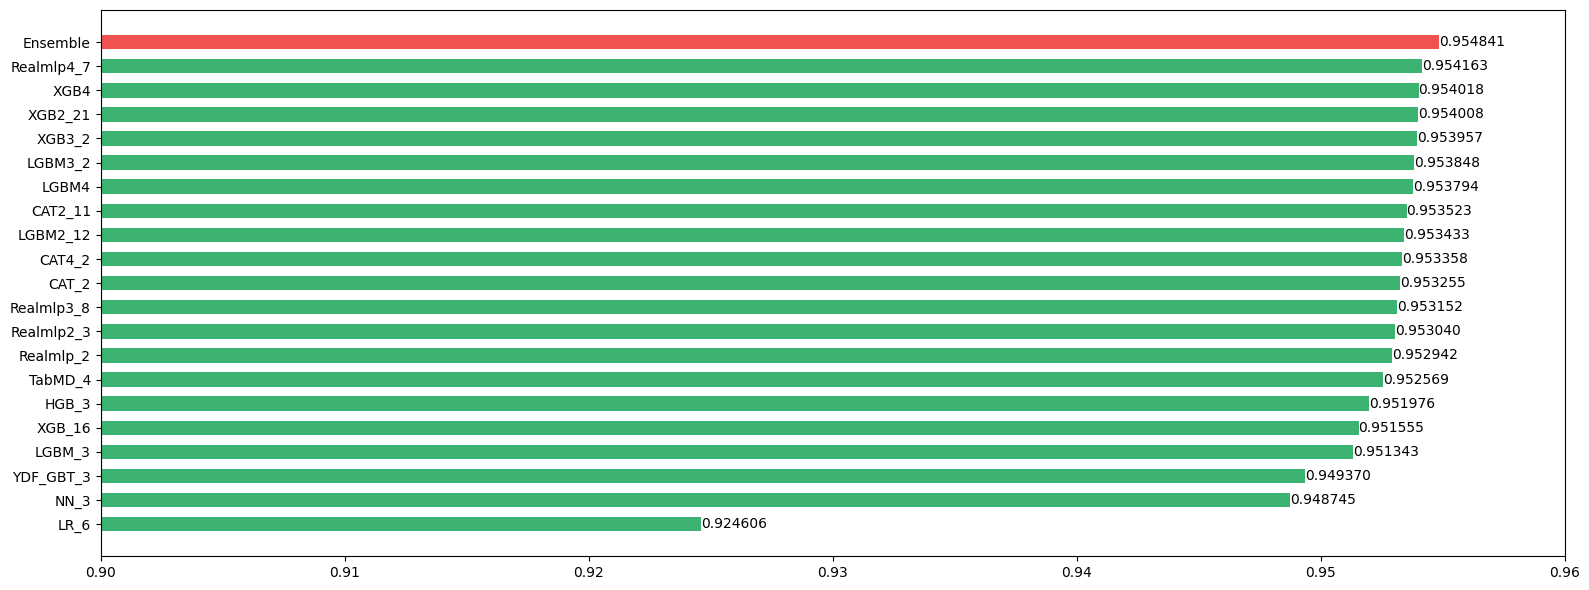

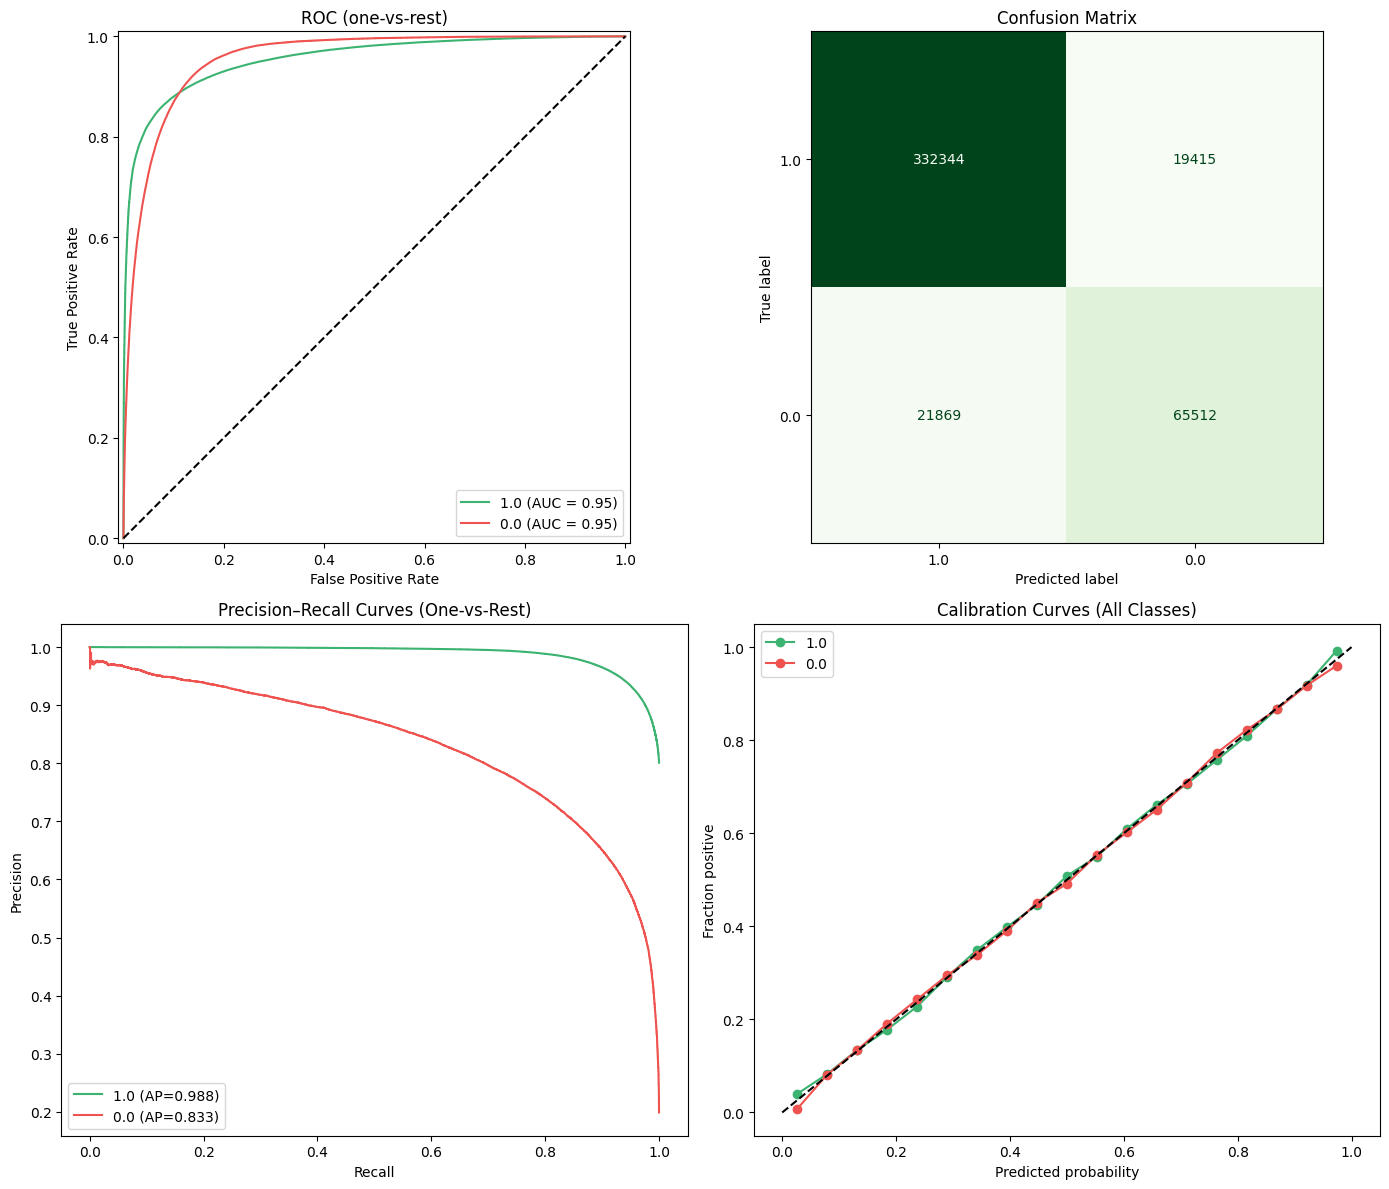

In [13]:
trainer = Trainer(X, y, test, models, num_features, cat_features, training=False)
TEST_preds, OOF_preds = trainer.run()

# <p style="border-radius: 40px; color: white; font-weight: bold; font-size: 150%; text-align: center; background-color:#3cb371; padding: 5px 5px 5px 5px;">Submission</p>

,id,PitNextLap
0,439140,0.004830
1,439141,0.024025
2,439142,0.007585
3,439143,0.203076
4,439144,0.829722


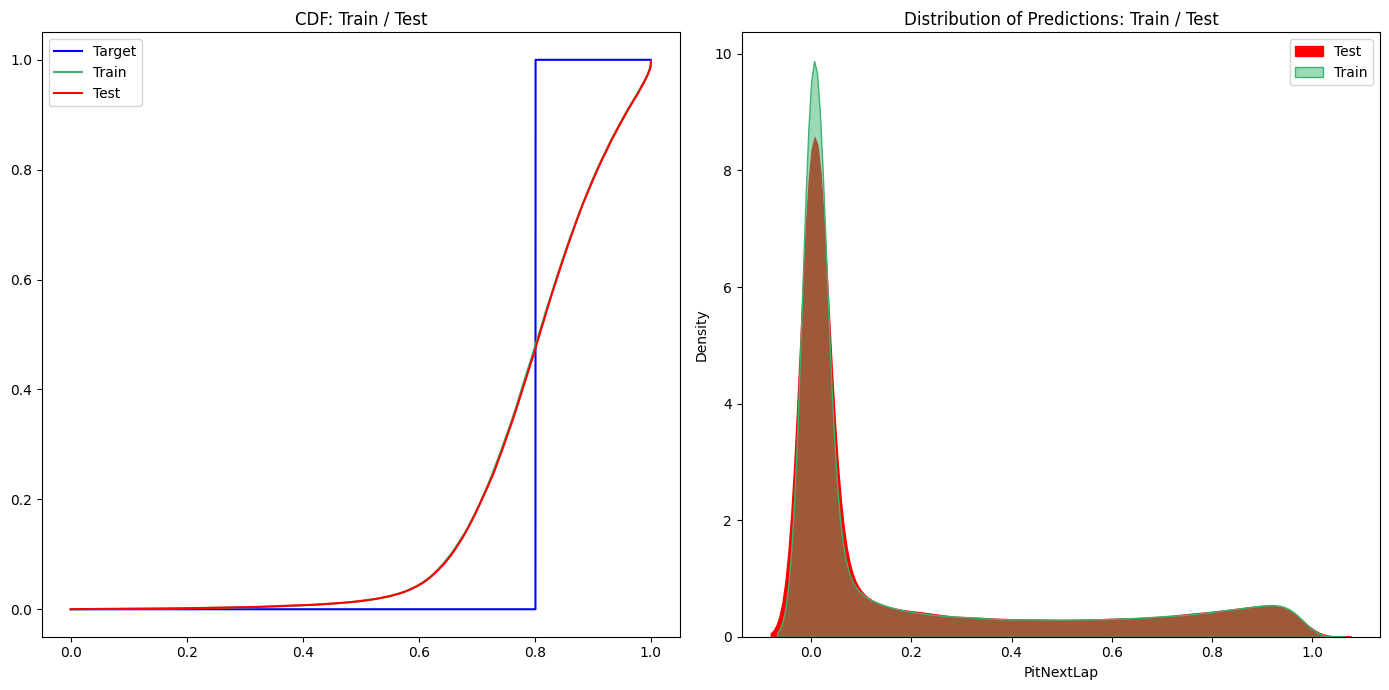

In [14]:
submission = Config.submission
submission[Config.target] = TEST_preds
submission.to_csv("submission.csv", index=False)

def plot_cdf(values, label, color, ax):
    sorted_vals = np.sort(values)
    y = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    ax.plot(y, sorted_vals, label=label, color=color)
    
display(submission.head())
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# CDF
plot_cdf(y, "Target", color='blue', ax=axes[0])
plot_cdf(OOF_preds, "Train", color='#3cb371', ax=axes[0])
plot_cdf(submission[Config.target], "Test", color='red', ax=axes[0])
axes[0].legend()
axes[0].set_title("CDF: Train / Test")

# KDE
sns.kdeplot(submission[Config.target], label='Test', fill=True, color='red', alpha=1., ax=axes[1])
sns.kdeplot(OOF_preds, label='Train', fill=True, color='#3cb371', alpha=0.5, ax=axes[1])
axes[1].set_title('Distribution of Predictions: Train / Test')
axes[1].legend()

plt.tight_layout()
plt.show()